In [3]:
!pwd

/tmp/truejit/evaluation/compilation-latency


In [4]:
import json
import matplotlib.pyplot as plt
import scipy.stats.mstats
import numpy as np

# font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [13]:
SUITES_NAMES = {'npb': 'NPB', 'polybench': 'Polybench', 'mibench': 'MiBench', 'wabench': 'WABench', 'spec': 'SPEC',
                'jetstream': 'JetStream', 'coremark': 'CoreMark', 'geomean': 'Geomean'}


def get_suites():
    suites = [
        {'name': 'polybench',
         'benchmarks': ['2mm', '3mm', 'adi', 'atax', 'bicg', 'cholesky', 'correlation', 'covariance', 'deriche',
                        'doitgen',
                        'durbin', 'fdtd-2d', 'floyd-warshall', 'gemm', 'gemver', 'gesummv', 'gramschmidt', 'heat-3d',
                        'jacobi-1d', 'jacobi-2d', 'lu', 'ludcmp', 'mvt', 'nussinov', 'seidel-2d', 'symm', 'syr2k',
                        'syrk',
                        'trisolv', 'trmm']},
        {'name': 'mibench',
         'benchmarks': ['basicmath', 'bitcount', 'cjpeg', 'djpeg', 'stringsearch', 'blowfish-decode', 'blowfish-encode',
                        'rijndael-decode', 'rijndael-encode', 'sha', 'rawcaudio', 'rawdaudio', 'crc32']},
        {'name': 'wabench',
         'benchmarks': ['bzip2', 'facedetection', 'gnuchess', 'espeak', 'mnist', 'snappy', 'whitedb']},
        {'name': 'spec',
         'benchmarks': ['lbm', 'mcf', 'x264',
                        'nab', 'namd'
                        ]},
        {'name': 'jetstream',
         'benchmarks': ['gcc-loops', 'float-mm', 'HashSet', 'quicksort', 'tsf']},
        {'name': 'npb',
         'benchmarks': ['bt', 'cg', 'ep', 'ft', 'is',
                        'lu', # we should comment it for the prediction depth experiment
                        'mg', 'sp']},
        {'name': 'coremark',
         'benchmarks': ['coremark']},
        {'name': 'geomean',
         'benchmarks': ['Geom.\nMean']},
    ]
    o = {}
    for s, suite in enumerate(suites):
        o[suite['name']] = {benchmark: {} for benchmark in suite['benchmarks']}
    return o


def augment_list(lst, n):
    lst = sorted(lst[:], reverse=True)
    avg = np.mean(lst[-10:])
    lst += [avg] * (n - len(lst))
    return lst[:n]

In [14]:
def process(input_file, schemes, repetitions):
    with open(input_file) as f:
        lines = f.readlines()
        lines = [result.strip() for result in lines]
        lines = [result for result in lines if result]
        lines = [json.loads(result) for result in lines]

    suites = get_suites()
    i = 0
    while i < len(lines):
        suite_name = lines[i]['Suite']
        # print(f"suite_name: {suite_name}")
        benchmark_name = lines[i]['Application']
        # print(f"benchmark_name: {benchmark_name}")
        for scheme in schemes:
            reps = []
            for r in range(repetitions):
                # print(f"r: {r}")
                assert lines[i]['Application'] == benchmark_name
                latencies = lines[i]['Latencies']
                latencies = augment_list(latencies, 10000)
                # print min, max, mean
                # if len(latencies) > 1:
                #     print(
                #         f'{suite_name} {benchmark_name} {scheme} {r} min:{min(latencies)} max:{max(latencies)} avg:{np.mean(latencies)}')
                latencies = np.mean(latencies)
                reps.append(latencies)
                i += 1
            if repetitions > 1:
                reps = reps[1:]  # remove the first one
            avg_latency = np.mean(reps)
            suites[suite_name][benchmark_name][scheme] = avg_latency

        baseline = suites[suite_name][benchmark_name][schemes[0]]
        for scheme in schemes:
            latencies = suites[suite_name][benchmark_name][scheme]
            relative_latencies = latencies / baseline
            relative_speedups = 1 / relative_latencies
            relative_speedups = round(relative_speedups, 2)
            suites[suite_name][benchmark_name][scheme] = relative_speedups

    # print(suites)

    for scheme in schemes:
        # print(f"Scheme: {scheme}")
        latencies = []
        for suite in suites.values():
            # print(f"suite: {suite}")
            for benchmark in suite:
                # print(f"benchmark: {benchmark}")
                if benchmark != 'Geom.\nMean':
                    # print(suite)
                    # pr
                    # print(suite[benchmark])
                    latencies.append(suite[benchmark][scheme])
        geomean = scipy.stats.mstats.gmean(latencies)
        suites['geomean']['Geom.\nMean'][scheme] = geomean

    return suites

In [15]:
input_file = 'in/compilation_speedups_comparison.prediction_depth.txt'
schemes = [f'{i}-gram-lstm' for i in [1, 2, 3, 4, 5, 10, 20, 50, 100, 200]]
repetitions = 1
suites = process(input_file, schemes, repetitions)

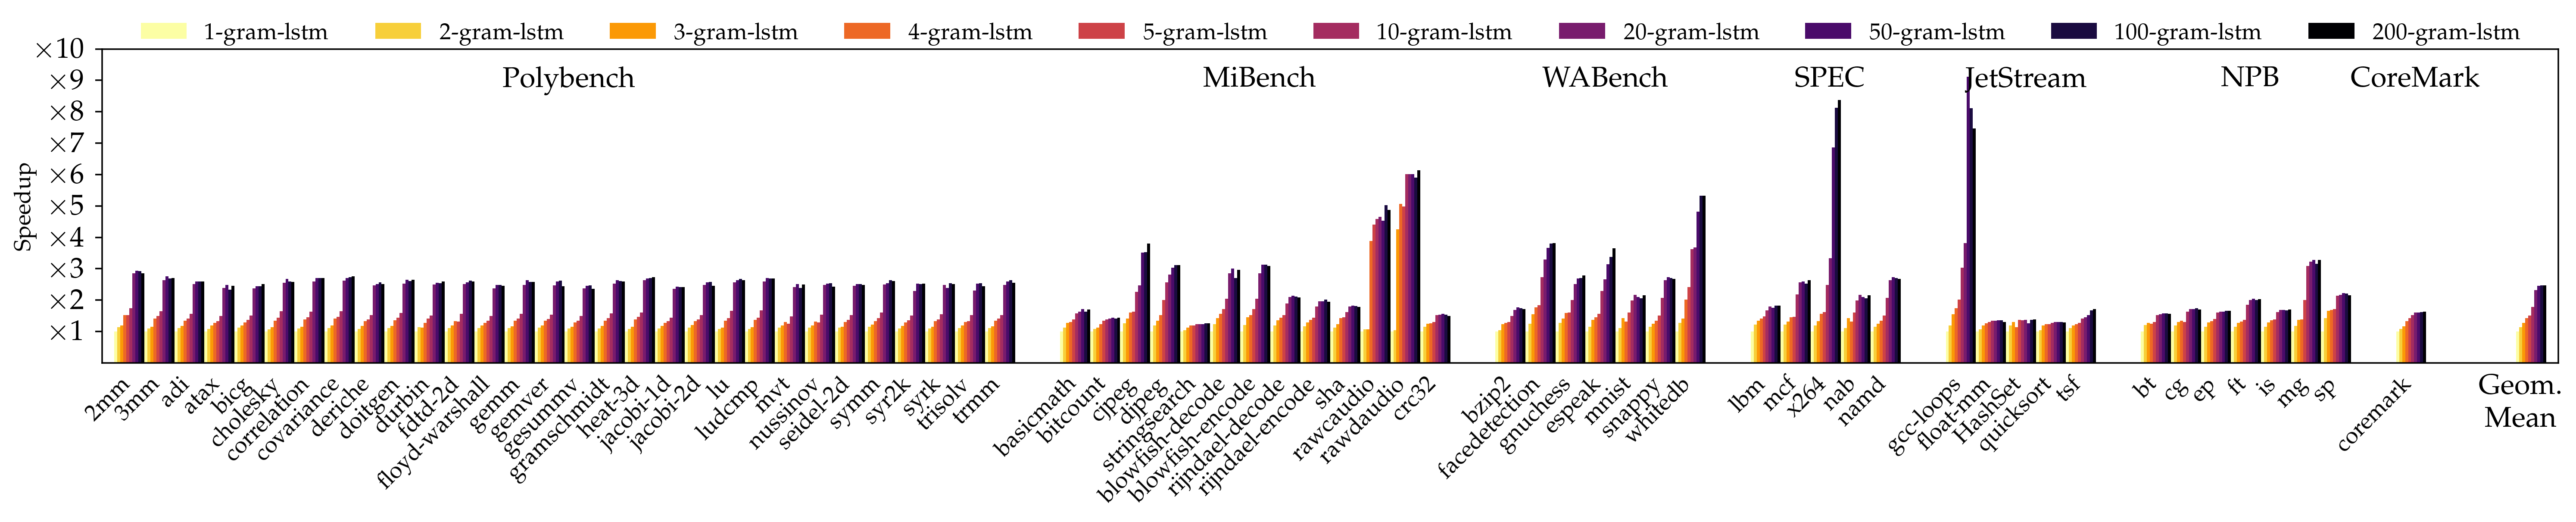

In [27]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors
colors = bokeh.palettes.inferno(len(schemes))
colors = colors[::-1]

# bars and spaces
bar_width = 1
scheme_bar_width = bar_width / len(schemes)
SPACE_BETWEEN_SUITES = 1.5

# figure
width = 20
height = 4
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
xs = []
for name, suite in suites.items():
    if name == 'geomean':
        suite_x += SPACE_BETWEEN_SUITES
    suite_x_start = suite_x
    for b, key in enumerate(suite.keys()):
        benchmark = suite[key]
        xs.append((suite_x + b, key))
        for s, scheme in enumerate(schemes):
            x = suite_x + b + (s - 1) * scheme_bar_width
            value = benchmark[scheme]
            color = colors[s]
            ax.bar(x, value, width=scheme_bar_width, color=color, edgecolor='none', linewidth=0.1)
    # write suite name on top middle of group of bars
    if name not in ['geomean']:
        x = suite_x_start + len(suite) / 2
        y = 9
        ax.text(x, y, SUITES_NAMES[name], ha='center', va='center', fontsize=15)
    suite_x += len(suite) + SPACE_BETWEEN_SUITES

# text on top of the geomean bar
# for s, scheme in enumerate(schemes[1:]):
#     x = suite_x - 1
#     geomean = suites['geomean']['Geom.\nMean'][scheme]
#     ax.text(x, geomean, f'$\\times{geomean:.1f}$', ha='left', va='center', fontsize=9)

# x-axis
x_ticks, x_labels = zip(*xs)
ax.set_xticks(x_ticks, x_labels, rotation=45, fontsize=12, ha='right', rotation_mode='anchor', va='top', y=0.01)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

geomean_label = ax.get_xticklabels()[-1]
geomean_label.set_fontsize(15)
geomean_label.set_rotation(0)
geomean_label.set_ha('center')

# y-axis
# ax.set_yscale('log')
ax.set_ylim((0, 10))
y_ticks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=15, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Speedup', fontsize=12, labelpad=0)

# margins
plt.margins(x=0.005, y=0)

# legend
legend = ax.legend(schemes,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.15),
                   ncol=len(schemes),
                   fontsize=12,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig('out/compilation_speedups_comparison.prediction_depth.pdf', bbox_inches='tight', pad_inches=0.01, dpi=320,
            transparent=True)

# show
plt.show()

In [5]:
input_file = 'in/compilation_latencies_comparison.network_latency.txt'
compilation_modes = ['Centralized JIT', 'TrueJIT']
network_latencies = ['0ms', '1ms', '2ms', '5ms', '10ms']
schemes = [f'{mode} ({latency})' for mode in compilation_modes for latency in network_latencies]
repetitions = 1
suites = process(input_file, schemes, repetitions)

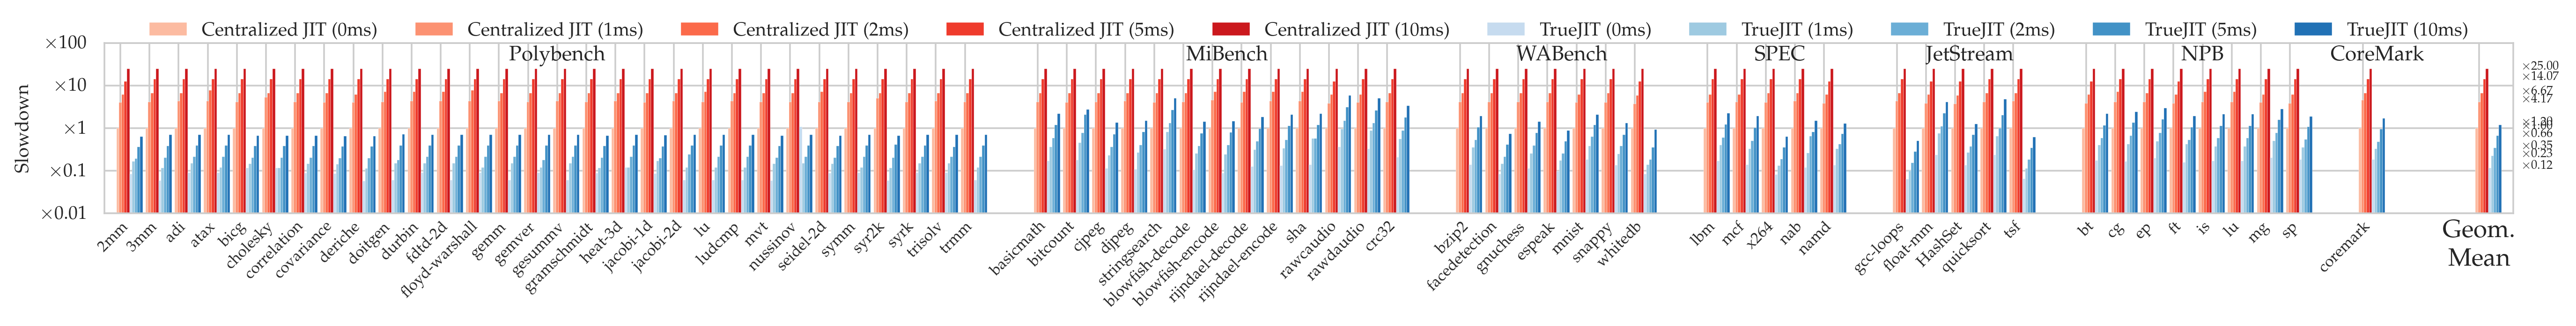

In [6]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors
colors = bokeh.palettes.Blues9[2:-2] + bokeh.palettes.Reds9[2:-2]
colors = colors[::-1]

# bars and spaces
bar_width = .9
scheme_bar_width = bar_width / len(schemes)
SPACE_BETWEEN_SUITES = 1.5

# figure
width = 18
height = 2.4
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
xs = []
for name, suite in suites.items():
    if name == 'geomean':
        suite_x += SPACE_BETWEEN_SUITES
    suite_x_start = suite_x
    for b, key in enumerate(suite.keys()):
        benchmark = suite[key]
        xs.append((suite_x + b, key))
        for s, scheme in enumerate(schemes):
            x = suite_x + b + (s - 1) * scheme_bar_width
            value = 1 / benchmark[scheme]
            color = colors[s]
            ax.bar(x, value, width=scheme_bar_width, color=color, edgecolor='white', linewidth=0.1)
    # write suite name on top middle of group of bars
    if name not in ['geomean']:
        x = suite_x_start + len(suite) / 2
        y = 50
        suites_names_fontsize = 10
        ax.text(x, y, SUITES_NAMES[name], ha='center', va='center', fontsize=suites_names_fontsize)
    suite_x += len(suite) + SPACE_BETWEEN_SUITES

# text next to the geomean bar
for s, scheme in enumerate(schemes[:]):
    x = suite_x - 1
    geomean = 1 / suites['geomean']['Geom.\nMean'][scheme]
    geomean_fontsize = 6
    ax.text(x, geomean, f'$\\times{geomean:.2f}$', fontsize=geomean_fontsize)

# x-axis
x_ticks, x_labels = zip(*xs)
benchmark_names_fontsize = 7.5
ax.set_xticks(x_ticks, x_labels, rotation=45, fontsize=benchmark_names_fontsize, ha='right', rotation_mode='anchor',
              va='top', y=0.05)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

geomean_label = ax.get_xticklabels()[-1]
geomean_label.set_fontsize(12)
geomean_label.set_rotation(0)
geomean_label.set_ha('center')

# y-axis
ax.set_yscale('log')
ax.set_ylim((.01, 100))
y_ticks = [10 ** i for i in range(-2, 3)]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=9, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Slowdown', fontsize=9)

# margins
plt.margins(x=0.005, y=0)

# legend
legend = ax.legend(schemes,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.22),
                   ncol=len(schemes),
                   fontsize=9,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig('out/compilation_latencies_comparison.network_latency.pdf', bbox_inches='tight', pad_inches=0.01,
            dpi=320, transparent=True)

# show
plt.show()

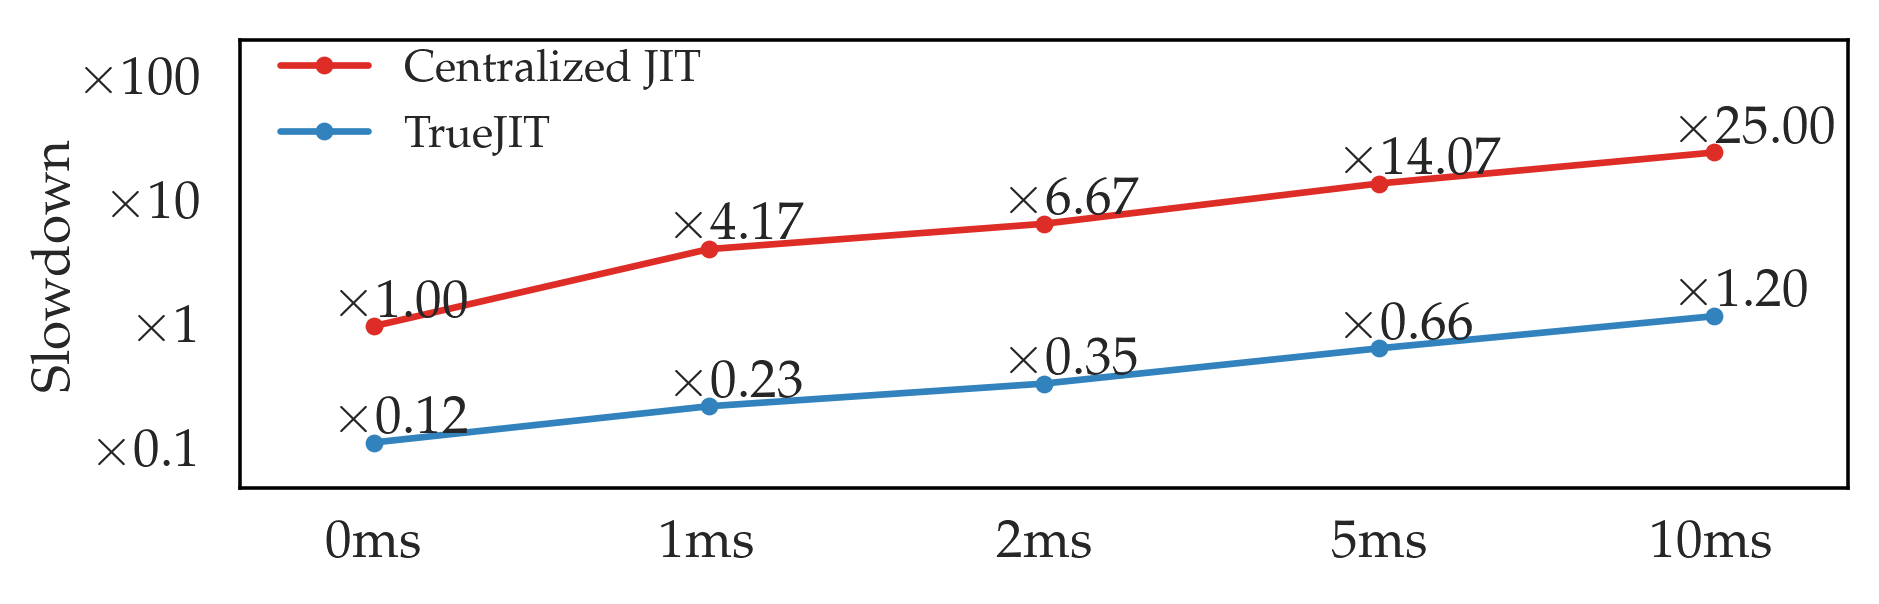

In [15]:
import matplotlib.pyplot as plt
import bokeh.palettes

# figure
width = 6
height = 2
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
benchmark = suites['geomean']['Geom.\nMean']
centralized_jit = []
for s, scheme in enumerate(schemes[:len(schemes) // 2]):
    value = 1 / benchmark[scheme]
    centralized_jit.append(value)
    ax.text(s - .1, (1.3) * value, f'$\\times{value:.2f}$', fontsize=12)
# print(centralized_jit)

truejit_times = []
for s, scheme in enumerate(schemes[len(schemes) // 2:]):
    value = 1 / benchmark[scheme]
    truejit_times.append(value)
    ax.text(s - .1, (1.3) * value, f'$\\times{value:.2f}$', fontsize=12)
# print(truejit_times)

plt.plot(network_latencies, centralized_jit, label='Centralized JIT', marker='.', color=bokeh.palettes.Reds[3][0])
plt.plot(network_latencies, truejit_times, label='TrueJIT', marker='.', color=bokeh.palettes.Blues[3][0])

# x-axis
# ax.set_xlim((-.5, 4.5))
# font size
ax.set_xticks(list(range(0, 5, 1)), network_latencies, fontsize=12)

# y-axis
ax.set_yscale('log')
ax.set_ylim((.05, 200))
y_ticks = [.1, 1, 10, 100]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=12, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Slowdown', fontsize=12, labelpad=0)

# margins
plt.margins(x=0.1, y=0)

# no grids
ax.grid(False)

# border is black
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# legend
legend = ax.legend(compilation_modes,
                   loc='upper left',
                   bbox_to_anchor=(0, 1.07),
                   ncol=1,
                   fontsize=10,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig('out/compilation_latencies_comparison.network_latency.geomean.pdf', bbox_inches='tight', pad_inches=0.01,
            dpi=320, transparent=True)

# show
plt.show()

In [25]:
input_file = 'in/compilation_speedups_comparison.key_results.txt'
schemes = ['Local JIT', 'Centralized JIT', 'TrueJIT']
repetitions = 3
suites = process(input_file, schemes, repetitions)

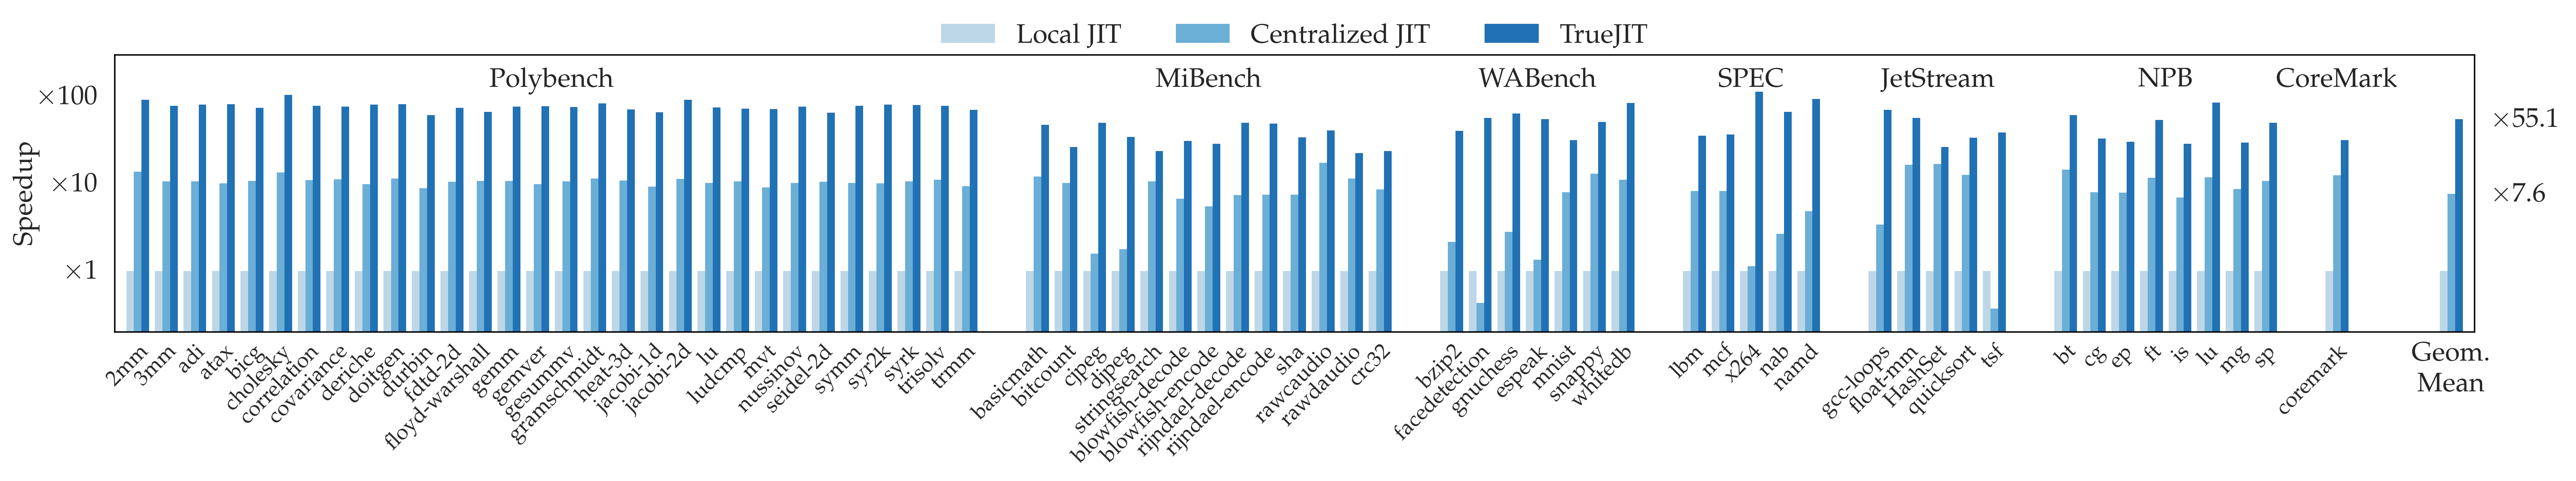

In [26]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors
colors = bokeh.palettes.Blues[len(schemes) + 1][:-1]
colors = colors[::-1]

# bars and spaces
bar_width = .8
scheme_bar_width = bar_width / len(schemes)
SPACE_BETWEEN_SUITES = 1.5

# figure
width = 20
height = 4
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
xs = []
for name, suite in suites.items():
    if name == 'geomean':
        suite_x += SPACE_BETWEEN_SUITES
    suite_x_start = suite_x
    for b, key in enumerate(suite.keys()):
        benchmark = suite[key]
        xs.append((suite_x + b, key))
        for s, scheme in enumerate(schemes):
            x = suite_x + b + (s - 1) * scheme_bar_width
            value = benchmark[scheme]
            color = colors[s]
            ax.bar(x, value, width=scheme_bar_width, color=color, edgecolor='none', linewidth=0.25)
    # write suite name on top middle of group of bars
    if name not in ['geomean']:
        x = suite_x_start + (len(suite) - 1) / 2
        y = 150
        ax.text(x, y, SUITES_NAMES[name], ha='center', va='center', fontsize=15)
    suite_x += len(suite) + SPACE_BETWEEN_SUITES

# text on top of the geomean bar
for s, scheme in enumerate(schemes[1:]):
    x = suite_x - 1
    geomean = suites['geomean']['Geom.\nMean'][scheme]
    ax.text(x, geomean, f'$\\times{geomean:.1f}$', ha='left', va='center', fontsize=15)

# x-axis
x_ticks, x_labels = zip(*xs)
ax.set_xticks(x_ticks, x_labels, rotation=45, fontsize=12, ha='right', rotation_mode='anchor', va='top', y=0.01)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

geomean_label = ax.get_xticklabels()[-1]
geomean_label.set_fontsize(15)
geomean_label.set_rotation(0)
geomean_label.set_ha('center')

# y-axis
ax.set_yscale('log')
ax.set_ylim((.2, 300))
y_ticks = [1, 10, 100]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=15, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Speedup', fontsize=15, labelpad=0)

# margins
plt.margins(x=0.005, y=0)

# no grids
ax.grid(False)

# border is black
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# legend
legend = ax.legend(schemes,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.2),
                   ncol=len(schemes),
                   fontsize=15,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig('out/compilation_speedups_comparison.pdf', bbox_inches='tight', pad_inches=0.01, dpi=320, transparent=True)

# show
plt.show()

In [28]:
input_file = 'in/compilation_latencies_comparison.cache_and_prediction.txt'
# schemes = ['Cold Cache, No Prediction', 'Warm Cache, No Prediction', 'Warm Cache, With Prediction']
schemes = ['Centralized JIT with Cold Cache', 'Centralized JIT with Warm Cache', 'TrueJIT with Warm Cache']
repetitions = 3
suites = process(input_file, schemes, repetitions)

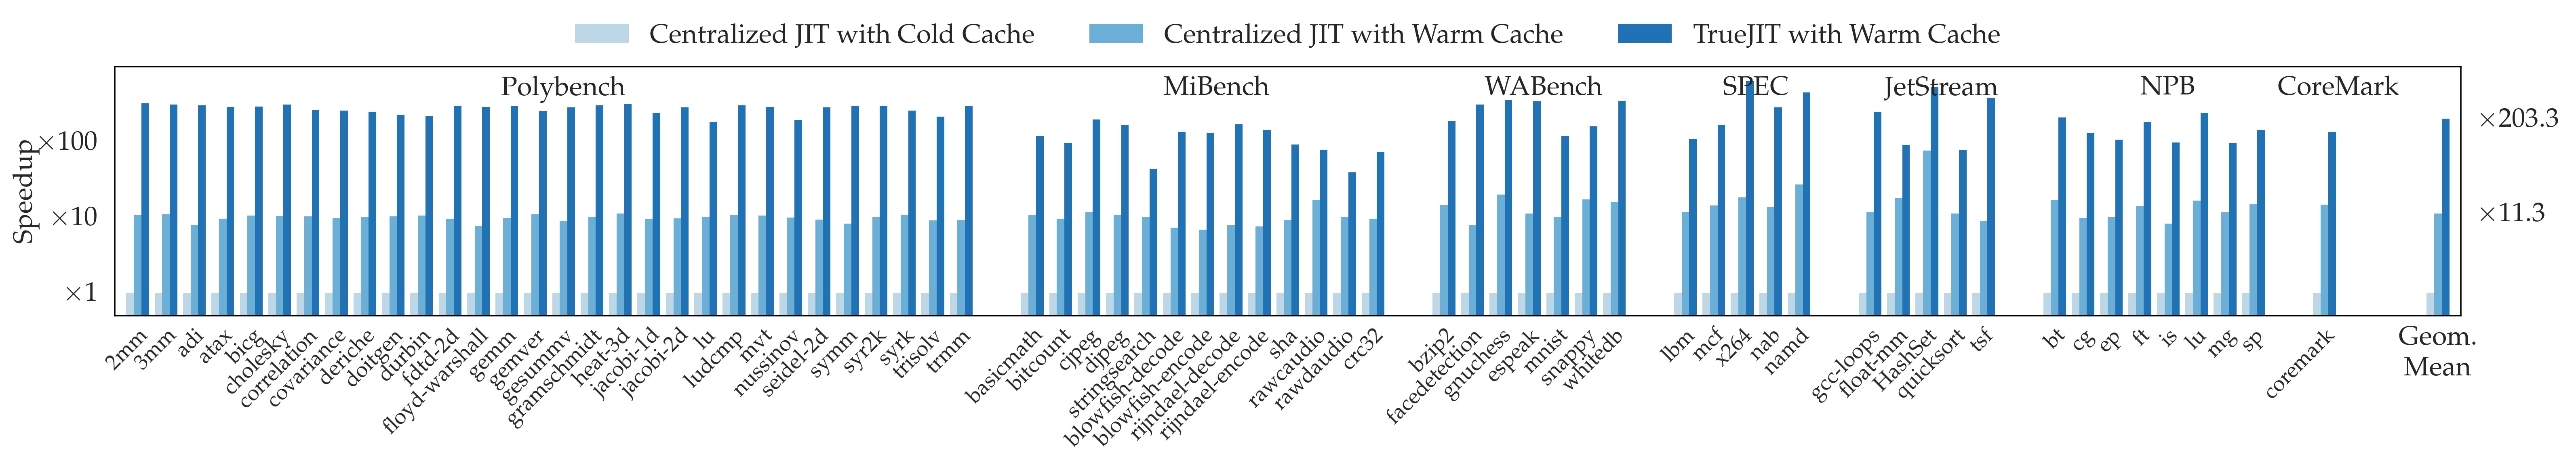

In [30]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors
colors = bokeh.palettes.Blues[len(schemes) + 1][:-1]
colors = colors[::-1]

# bars and spaces
bar_width = .8
scheme_bar_width = bar_width / len(schemes)
SPACE_BETWEEN_SUITES = 1.5

# figure
width = 20
height = 4
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
xs = []
for name, suite in suites.items():
    if name == 'geomean':
        suite_x += SPACE_BETWEEN_SUITES
    suite_x_start = suite_x
    for b, key in enumerate(suite.keys()):
        benchmark = suite[key]
        xs.append((suite_x + b, key))
        for s, scheme in enumerate(schemes):
            x = suite_x + b + (s - 1) * scheme_bar_width
            value = benchmark[scheme]
            color = colors[s]
            ax.bar(x, value, width=scheme_bar_width, color=color, edgecolor='none', linewidth=0.25)
    # write suite name on top middle of group of bars
    if name not in ['geomean']:
        x = suite_x_start + len(suite) / 2
        y = 500
        ax.text(x, y, SUITES_NAMES[name], ha='center', va='center', fontsize=15)
    suite_x += len(suite) + SPACE_BETWEEN_SUITES

# text on top of the geomean bar
for s, scheme in enumerate(schemes[1:]):
    x = suite_x - 1
    geomean = suites['geomean']['Geom.\nMean'][scheme]
    ax.text(x, geomean, f'$\\times{geomean:.1f}$', ha='left', va='center', fontsize=15)

# x-axis
x_ticks, x_labels = zip(*xs)
ax.set_xticks(x_ticks, x_labels, rotation=45, fontsize=12, ha='right', rotation_mode='anchor', va='top', y=0.01)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

geomean_label = ax.get_xticklabels()[-1]
geomean_label.set_fontsize(15)
geomean_label.set_rotation(0)
geomean_label.set_ha('center')

# y-axis
ax.set_yscale('log')
ax.set_ylim((.5, 1000))
y_ticks = [1, 10, 100]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=15, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Speedup', fontsize=15, labelpad=0)

# margins
plt.margins(x=0.005, y=0)

# no grids
ax.grid(False)

# border is black
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# legend
legend = ax.legend(schemes,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.27),
                   ncol=len(schemes),
                   fontsize=15,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig(
    'out/compilation_speedups_comparison.cache_and_prediction.pdf',
    bbox_inches='tight',
    pad_inches=0.01,
    dpi=320,
    transparent=True
)

# show
plt.show()